In [1]:
import pandas as pd
import numpy as np
import copy as cp
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv(r"C:\Users\SHREYAS ROY\Desktop\Manipal Work Documents\train.csv")
test = pd.read_csv(r"C:\Users\SHREYAS ROY\Desktop\Manipal Work Documents\test.csv") #File is NOT in same directory as Jupyter Notebook

train = train.dropna() #can be changed later to fillna() with mean, median, forward/backward fill, *forward/backward mean fill
#print(train.head())
test = test.dropna()
train = pd.get_dummies(train, columns = ['symbols'], drop_first = True) #auto performs one hot encoding and creates new categories acc; 
#drop_first -> k-1 hot encoding
test = pd.get_dummies(test, columns = ['symbols'], drop_first = True)
test = test.reindex(columns=train.columns, fill_value=0) # To Align columns of test wrt train
# - Run this line after reseting jupyter notebook and comment it out afterwards, or dont run this cell again
#print(train.head())

In [3]:
targetCol = 'close'
rawFeatures = train.drop(columns = [targetCol, 'date']).to_numpy() #x_i, for 1<=i<=m; Mean/ Z-score normalization of most features are still required
target = train[targetCol].to_numpy() #y
rawTestFeatures = test.drop(columns = [targetCol, 'date']).to_numpy()
testCases = test[targetCol].to_numpy()
#print(target)

In [4]:
# Mean Minmax Normalization:
# NOTE: 'symbols' which were one hot encoded, may be exempt from normalization
features = np.zeros(rawFeatures.shape)
mean = np.mean(rawFeatures, axis = 0) # axis = 0 -> column accessing
maxVal = np.max(rawFeatures, axis = 0)
minVal = np.min(rawFeatures, axis = 0)
features = (rawFeatures - mean) / (maxVal - minVal)

testFeatures = np.zeros(rawTestFeatures.shape)
testFeatures = (rawTestFeatures - mean) / (maxVal - minVal) # NOTE: Same mean, minVal, maxVal are used..

In [7]:
"""# Required for np.std computation
rawFeatures = rawFeatures.astype(np.float64) #Originally dtype was 'object' instead of float
rawTestFeatures = rawTestFeatures.astype(np.float64)

# Z-Score Normalization
mean = np.mean(rawFeatures, axis=0) #Returns an array of mean of all features
std = np.std(rawFeatures, axis=0)
# NOTE: 'symbols' which were one hot encoded, may be exempt from normalization
features = (rawFeatures - mean) / std # Assume std can never be 0

# Use training mean and std for test set
testFeatures = (rawTestFeatures - mean) / std"""

In [5]:
def costFunction(x, y, w, b) -> float:
    m = x.shape[0]
    yPred = np.dot(x,w) + b #x -> array of arrays, w -> a single weight vector
    error = yPred - y
    totalCost = np.dot(error, error) / (2*m)
    return totalCost

In [6]:
def computeGradient(x, y, w, b) -> tuple:
    m = x.shape[0]
    dw, db = 0, 0
    yPred = np.dot(x, w) + b
    error = yPred - y
    dw = np.dot(x.T, error) / m # dot product acts as matrix multiplication
    db = np.sum(error) / m
    return dw, db

In [7]:
def gradientDescent(features, target, wIn, b, alpha, iterations) -> tuple:
    m = features.shape[0]
    #For Graphing purposes:
    J_history = []
    w = cp.deepcopy(wIn)
    for i in range(0, iterations + 1):
        dw, db = computeGradient(features, target, w, b)
        w = w - alpha * dw
        b = b - alpha * db
        if i % (iterations // 10) == 0:
            cost = costFunction(features, target, w, b)
            J_history.append(cost)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")
    return w, b, J_history

In [ ]:
wIn = np.zeros(features.shape[1])
w, b , J_history = gradientDescent(features, target, wIn, 0, 0.01, 20_000)

Iteration    0: Cost  4893.25   
Iteration 2000: Cost  1529.46   
Iteration 4000: Cost  1065.70   
Iteration 6000: Cost   799.53   


In [13]:
predicted = np.dot(testFeatures, w) + b # auto creates an array of appropriate shape

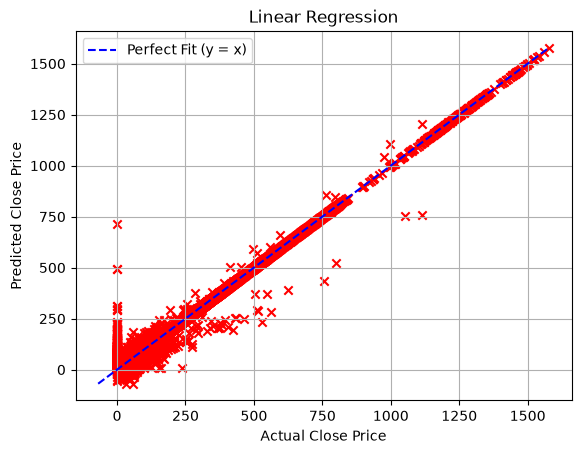

In [14]:
yPred = np.dot(features, w) + b
# Create a scatter plot of the data. 
plt.scatter(target, yPred, marker='x', c='r') # yActual vs yPred
# Reference diagonal line (Perfect model line where y_actual == y_pred)
min_val = min(target.min(), yPred.min())
max_val = max(target.max(), yPred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'b--', label='Perfect Fit (y = x)')
# Set the title
plt.title("Linear Regression")
# Set the y-axis label
plt.ylabel('Predicted Close Price')
# Set the x-axis label
plt.xlabel('Actual Close Price')
plt.legend()
plt.grid(True)
plt.show()


TEST SET EVALUATION: 
Test Cost J(w,b)     : 99.4420
Root Mean Sq Error   : $14.10 (Average deviation)
Mean Absolute Error  : $10.81
R² Score             : 0.9649 (96.49% fit)
Model Accuracy       : 83.44%


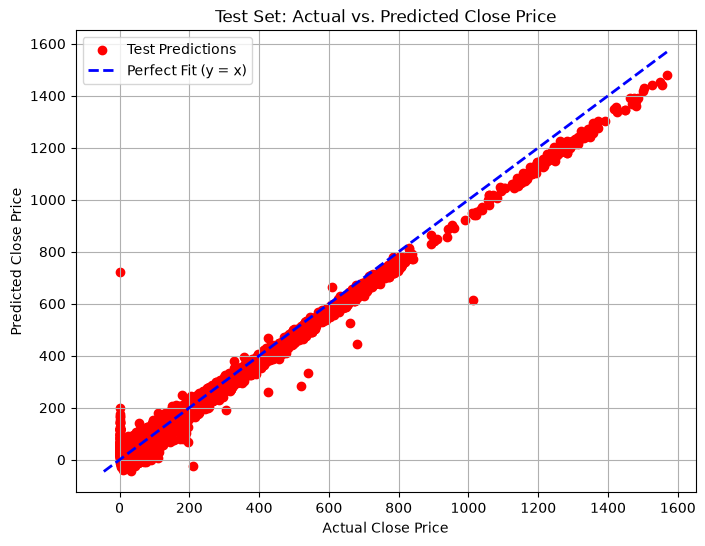

In [15]:
predicted_test = np.dot(testFeatures, w) + b
#predicted_test = np.clip(np.dot(testFeatures, w) + b, a_min=0, a_max=None) # It is noticed that sometimes our predicted values are less than 0 at Actual Close Price < 125, hence we are discarding those values

mse = np.mean((predicted_test - testCases) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(predicted_test - testCases))

ss_res = np.sum((testCases - predicted_test) ** 2)
ss_tot = np.sum((testCases - np.mean(testCases)) ** 2)
r2_score = 1 - (ss_res / ss_tot) # R-squared Score

nonZeroTestCases = testCases != 0 # V imp
wmape = np.sum(np.abs(testCases[nonZeroTestCases] - predicted_test[nonZeroTestCases]) / np.sum(testCases[nonZeroTestCases])) * 100
# mape is being biased with small Actual Close Price values, henc we use wmape 
accuracy_pct = 100 - wmape

# 3. Print Results
print("TEST SET EVALUATION: ")
print(f"Test Cost J(w,b)     : {mse / 2.0:.4f}")
print(f"Root Mean Sq Error   : ${rmse:.2f} (Average deviation)")
print(f"Mean Absolute Error  : ${mae:.2f}")
print(f"R² Score             : {r2_score:.4f} ({r2_score * 100:.2f}% fit)")
print(f"Model Accuracy       : {accuracy_pct:.2f}%")

# 4. Plot Test Predictions vs Actual Test Prices
plt.figure(figsize=(8, 6))
plt.scatter(testCases, predicted_test, marker='o', c='red', label='Test Predictions')

# Reference diagonal line for perfect fit
min_val = min(testCases.min(), predicted_test.min())
max_val = max(testCases.max(), predicted_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'b--', linewidth=2, label='Perfect Fit (y = x)')

plt.title("Test Set: Actual vs. Predicted Close Price")
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.legend()
plt.grid(True)
plt.show()